In [1]:
! pip install pandas numpy matplotlib seaborn rdkit scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 57.5 MB/s eta 0:00:00


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from sklearn.decomposition import PCA

In [3]:
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/Lipophilicity.csv"

df = pd.read_csv(url)

print(df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

(4200, 3)

Columns:
['CMPD_CHEMBLID', 'exp', 'smiles']


,CMPD_CHEMBLID,exp,smiles
0,CHEMBL596271,3.54,Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14
1,CHEMBL1951080,-1.18,COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...
2,CHEMBL1771,3.69,COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl
3,CHEMBL234951,3.37,OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...
4,CHEMBL565079,3.10,Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...


In [4]:
def smiles_to_mol(smiles):
  return Chem.MolFromSmiles(smiles)

df["mol"] = df["smiles"].apply(smiles_to_mol)

df["valid_smiles"] = df["mol"].notna()

print(df["valid_smiles"].value_counts())

valid_smiles
True    4200
Name: count, dtype: int64


In [5]:
df = df[df["valid_smiles"]].copy()

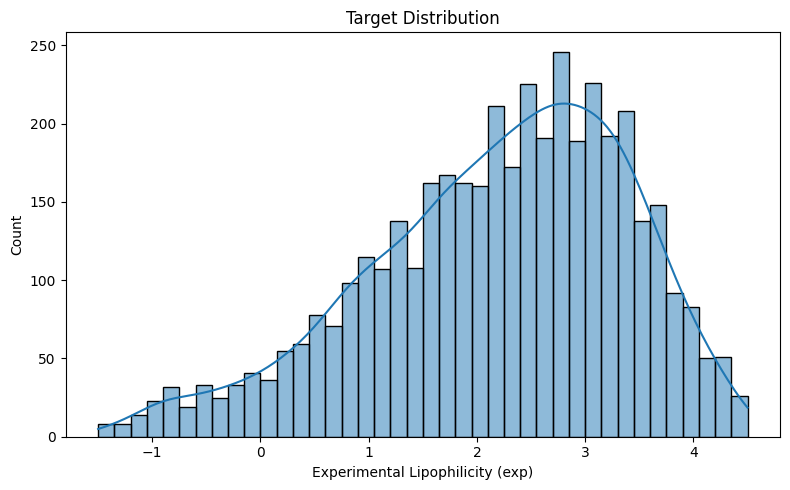

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df["exp"], bins=40, kde=True)
plt.xlabel("Experimental Lipophilicity (exp)")
plt.title("Target Distribution")
plt.tight_layout()
plt.show()

In [7]:
def calculate_descriptors(mol):

  descriptors = {
      "MolWt": Descriptors.MolWt(mol),
      "LogP": Descriptors.MolLogP(mol),
      "TPSA": Descriptors.TPSA(mol),
      "HBD": Descriptors.NumHDonors(mol),
      "HBA": Descriptors.NumHAcceptors(mol),
      "RotatableBonds": Descriptors.NumRotatableBonds(mol),
      "RingCount": Descriptors.RingCount(mol),
      "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),
      "FractionCSP3": Descriptors.FractionCSP3(mol),
      "NumAromaticRings": Descriptors.NumAromaticRings(mol)
  }

  return pd.Series(descriptors)

descriptor_df = df["mol"].apply(calculate_descriptors)

df = pd.concat(
    [df.reset_index(drop=True),
     descriptor_df.reset_index(drop=True)],
    axis=1
)

df.head()

,CMPD_CHEMBLID,exp,smiles,mol,valid_smiles,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,RingCount,HeavyAtomCount,FractionCSP3,NumAromaticRings
0,CHEMBL596271,3.54,Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14,<rdkit.Chem.rdchem.Mol object at 0x7de9142a5850>,True,340.858,3.5489,24.30,0.0,3.0,3.0,4.0,24.0,0.315789,3.0
1,CHEMBL1951080,-1.18,COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...,<rdkit.Chem.rdchem.Mol object at 0x7de9142a58c0>,True,494.591,2.9901,122.24,2.0,7.0,9.0,3.0,33.0,0.363636,2.0
2,CHEMBL1771,3.69,COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl,<rdkit.Chem.rdchem.Mol object at 0x7de9142a5930>,True,321.829,3.6739,29.54,0.0,4.0,3.0,3.0,21.0,0.312500,2.0
3,CHEMBL234951,3.37,OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...,<rdkit.Chem.rdchem.Mol object at 0x7de9142a59a0>,True,419.890,1.9237,105.66,4.0,5.0,5.0,4.0,28.0,0.263158,3.0
4,CHEMBL565079,3.10,Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...,<rdkit.Chem.rdchem.Mol object at 0x7de9142a5a10>,True,381.480,2.0069,99.81,2.0,4.0,6.0,2.0,28.0,0.428571,2.0


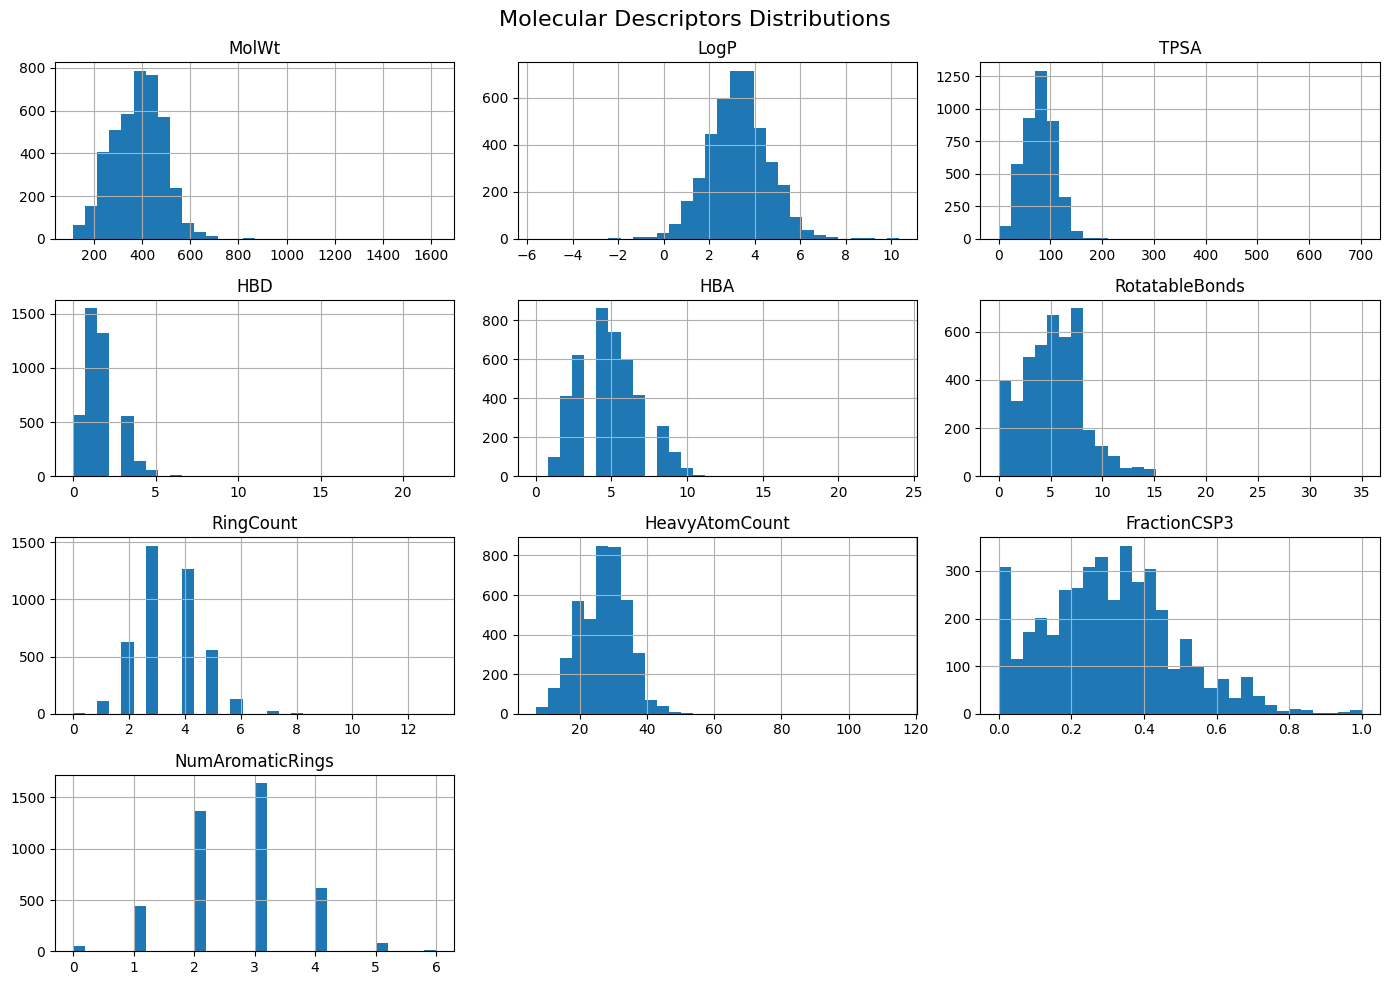

In [8]:
all_descriptor_columns = [
    "MolWt", "LogP", "TPSA", "HBD", "HBA",
    "RotatableBonds", "RingCount", "HeavyAtomCount",
    "FractionCSP3", "NumAromaticRings"
]

df[all_descriptor_columns].hist(
     figsize=(14, 10),
     bins=30
)
plt.suptitle(
    "Molecular Descriptors Distributions",
     fontsize=16
)

plt.tight_layout()
plt.show()

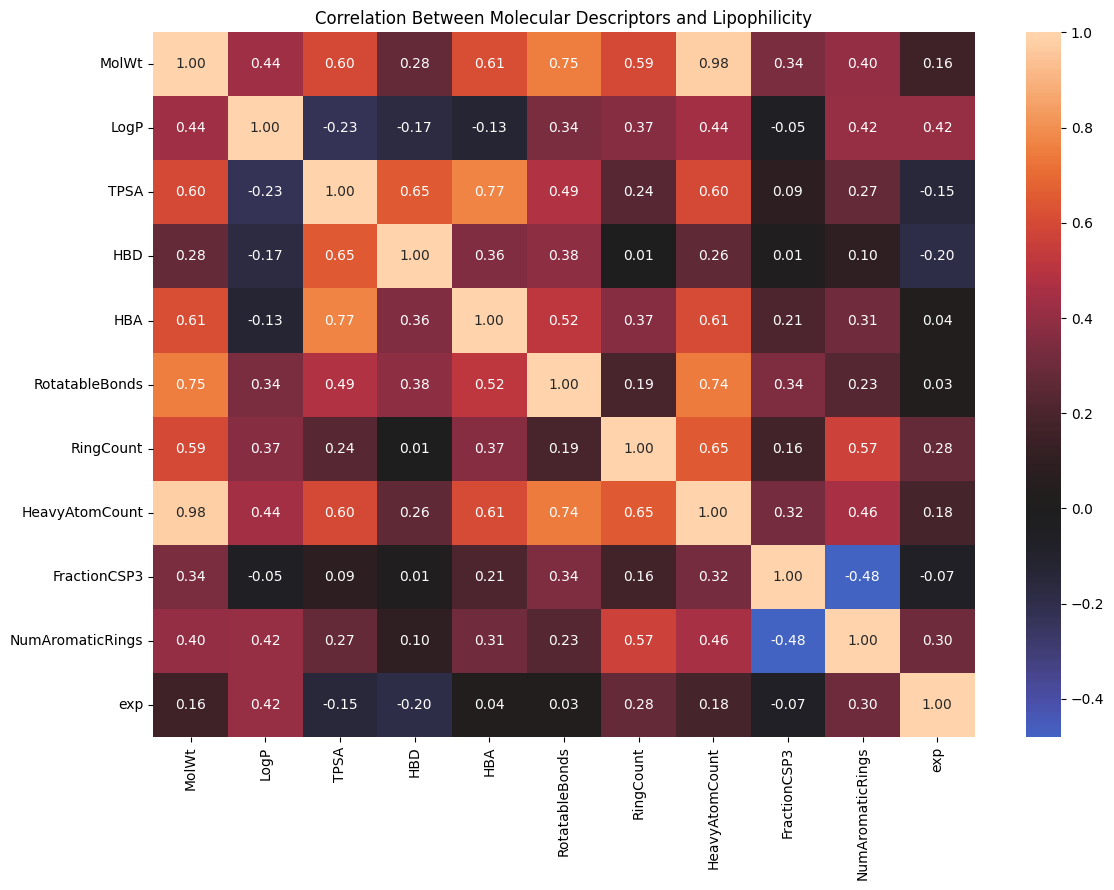

Correlation between exp and LogP: 0.41545012311806534


In [28]:
correlation_columns = all_descriptor_columns + ["exp"]

corr_matrix = df[correlation_columns].corr()
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlation Between Molecular Descriptors and Lipophilicity")

plt.tight_layout()
plt.show()

print("Correlation between exp and LogP:", corr_matrix.loc["LogP", "exp"])

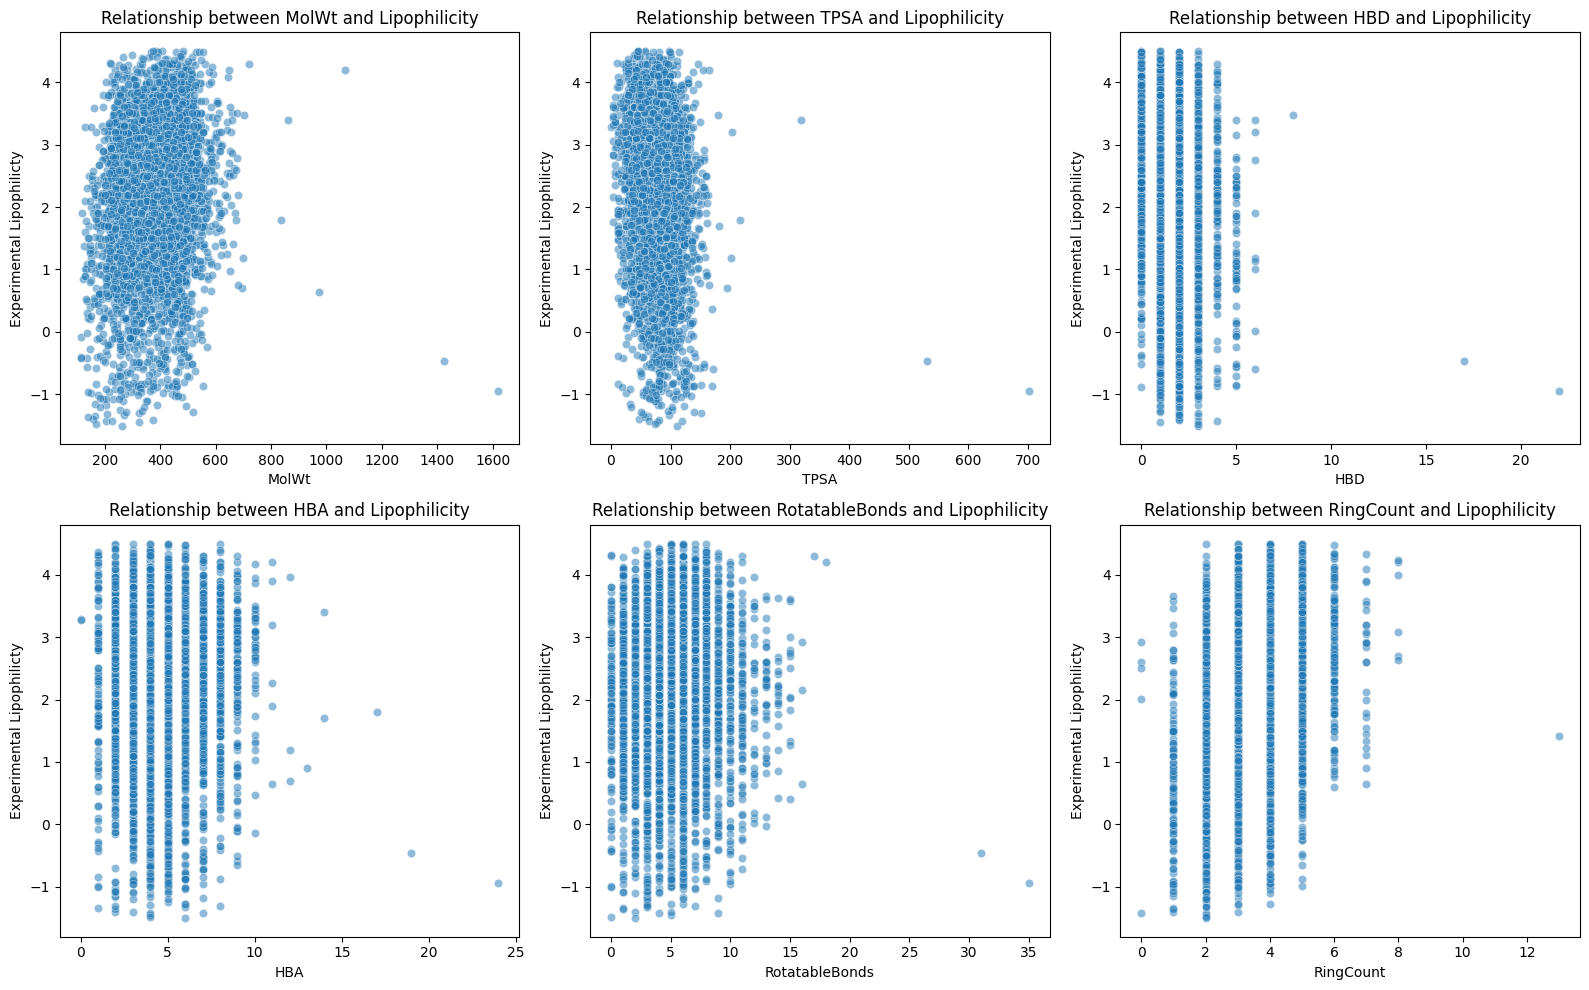

In [10]:
features_to_plot = [
    "MolWt", "TPSA", "HBD", "HBA", "RotatableBonds", "RingCount"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, feature in zip(axes.flatten(), features_to_plot):

    sns.scatterplot(
      data=df,
      x=feature,
      y="exp",
      alpha=0.5,
      ax=ax
    )

    ax.set_title(f"Relationship between {feature} and Lipophilicity")
    ax.set_xlabel(feature)
    ax.set_ylabel("Experimental Lipophilicty")

plt.tight_layout()
plt.show()

In [11]:
descriptor_columns = [
 "MolWt", "TPSA", "HBD", "HBA", "RotatableBonds",
 "RingCount", "HeavyAtomCount", "FractionCSP3", "NumAromaticRings"
]

x = df[descriptor_columns]
y = df["exp"]

print("Feature matrix shape:", x.shape)
print("Target shape:", y.shape)

Feature matrix shape: (4200, 9)
Target shape: (4200,)


In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

print("Training set:", x_train.shape)
print("Test set:", x_test.shape)

Training set: (3360, 9)
Test set: (840, 9)


In [13]:
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)
linear_predictions = linear_model.predict(x_test)

In [14]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)



print("Linear Regression")
print("------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R2:", linear_r2)

Linear Regression
------------------
MAE : 0.8593249109260157
RMSE: 1.0760964748013748
R2: 0.2162412056149089


In [15]:
poly_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
])

poly_model.fit(x_train, y_train)
poly_predictions = poly_model.predict(x_test)

In [16]:
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

svr_model.fit(x_train, y_train)
svr_predictions = svr_model.predict(x_test)

In [17]:
tree_model = DecisionTreeRegressor(max_depth=8, random_state=42)
tree_model.fit(x_train, y_train)
tree_predictions = tree_model.predict(x_test)

In [18]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train)
rf_predictions = rf_model.predict(x_test)

In [19]:
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs= -1
)

grid_search.fit(x_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R2:", grid_search.best_score_)

rf_best_model = grid_search.best_estimator_
rf_best_predictions = rf_best_model.predict(x_test)


Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best CV R2: 0.42234935415290115


In [20]:
models = {
    "Linear Regression": linear_predictions,
    "Polynomial Regression": poly_predictions,
    "SVR": svr_predictions,
    "Decision Tree": tree_predictions,
    "Random Forest": rf_predictions,
    "Random Forest (Tuned)": rf_best_predictions
}

results = []

for model_name, predictions in models.items():

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE")
print(results_df)

                   Model       MAE      RMSE        R2
5  Random Forest (Tuned)  0.666906  0.899513  0.452361
4          Random Forest  0.667339  0.899817  0.451991
2                    SVR  0.747256  0.974837  0.356802
1  Polynomial Regression  0.813423  1.070295  0.224669
3          Decision Tree  0.825614  1.072279  0.221792
0      Linear Regression  0.859325  1.076096  0.216241


In [21]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("linear", LinearRegression())
    ]),
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf"))
    ]),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    )
}

cv_results = []

for model_name, model in cv_models.items():
    scores = cross_val_score(
        model, x, y, cv=cv, scoring="r2", n_jobs=-1
    )
    cv_results.append({
        "Model": model_name,
        "R2_mean": scores.mean(),
        "R2_std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.sort_values(by="R2_mean", ascending=False)


,Model,R2_mean,R2_std
4,Random Forest,0.452075,0.013297
2,SVR,0.363228,0.021368
1,Polynomial Regression,0.246212,0.037948
3,Decision Tree,0.243988,0.026346
0,Linear Regression,0.221678,0.010973


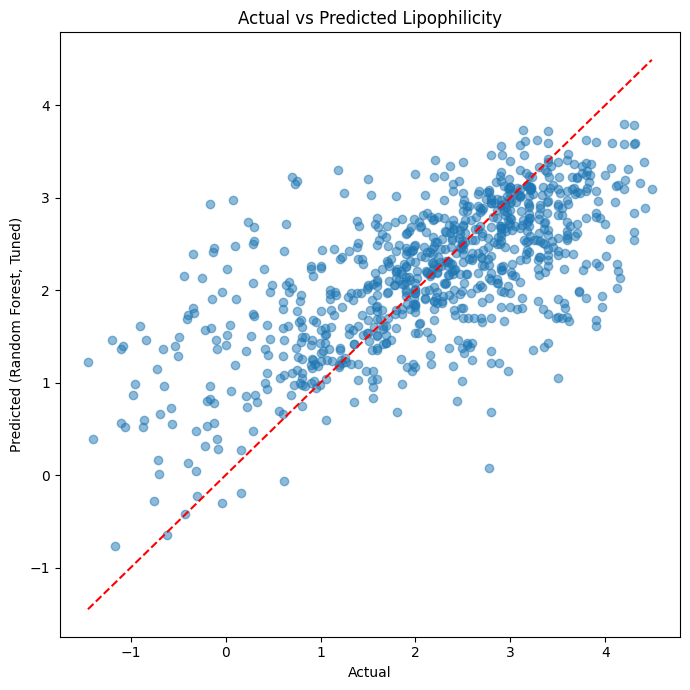

In [22]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, rf_best_predictions, alpha=0.5)
plt.plot(
 [y_test.min(), y_test.max()],
 [y_test.min(), y_test.max()],
 "r--"
)
plt.xlabel("Actual")
plt.ylabel("Predicted (Random Forest, Tuned)")
plt.title("Actual vs Predicted Lipophilicity")
plt.tight_layout()
plt.show()


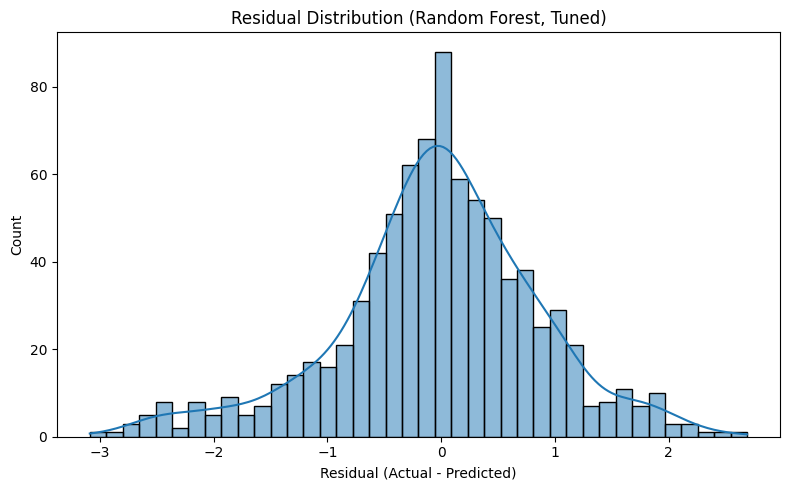

In [23]:
residuals = y_test - rf_best_predictions
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.xlabel("Residual (Actual - Predicted)")
plt.title("Residual Distribution (Random Forest, Tuned)")
plt.tight_layout()
plt.show()

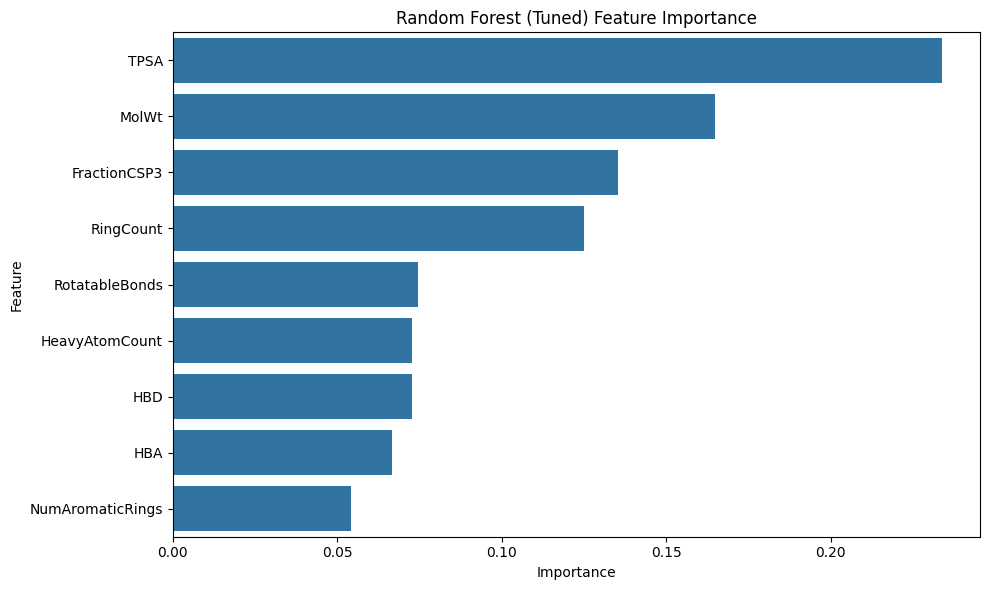

In [24]:
feature_importance = pd.DataFrame({
 "Feature": x_train.columns,
 "Importance": rf_best_model.feature_importances_
})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Random Forest (Tuned) Feature Importance")
plt.tight_layout()
plt.show()

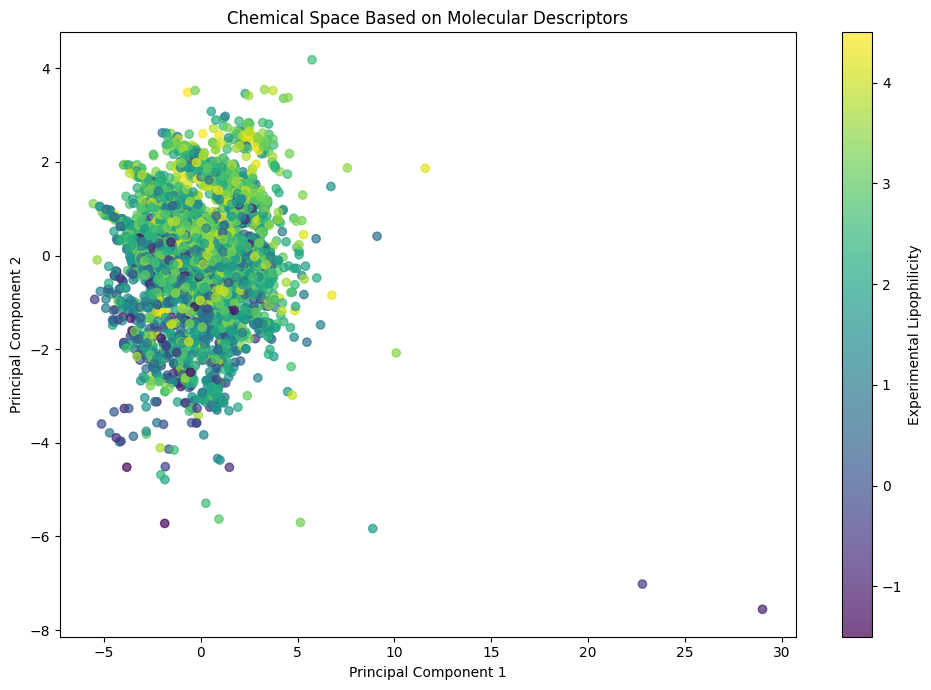

In [25]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame(x_pca, columns=["PC1", "PC2"])
pca_df["Lipophilicity"] = y.values

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
 pca_df["PC1"], pca_df["PC2"],
 c=pca_df["Lipophilicity"],
 alpha=0.7
)
plt.colorbar(scatter, label="Experimental Lipophilicity")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Chemical Space Based on Molecular Descriptors")
plt.tight_layout()
plt.show()

In [26]:
error_df = pd.DataFrame({
 "SMILES": df.loc[x_test.index, "smiles"],
 "Actual": y_test,
 "Predicted": rf_best_predictions
})
error_df["Absolute_Error"] = (error_df["Actual"] - error_df["Predicted"]).abs()

worst_predictions = error_df.sort_values(by="Absolute_Error", ascending=False)
worst_predictions.head(10)

,SMILES,Actual,Predicted,Absolute_Error
3103,OC(=O)COc1ccc(cc1c2ccccc2)c3nccs3,-0.16,2.929786,3.089786
4178,OC(=O)[C@H](Cc1ccc(cc1)N2CCN(CC2)c3ccccc3)NC(=...,0.08,2.975605,2.895605
1973,Cc1ccc2c(c1)c(c(C)n2CC(=O)O)c3ccnc4c(cccc34)S(...,-0.34,2.388457,2.728457
690,CCS(=O)(=O)c1ccc(c(C)c1)c2cc(ccc2OCC(=O)N)C(F)...,2.77,0.080070,2.689930
1344,CN(C)c1cccc2c(cccc12)S(=O)(=O)N(C)CC(=O)O,-1.45,1.226403,2.676403
4104,CCN1CCCC1CNC(=O)c2cc(ccc2OC)S(=O)(=O)N,-1.20,1.463947,2.663947
2029,Cc1c(CC(=O)O)c2cc(F)ccc2n1S(=O)(=O)c3ccc(cc3)S...,-0.44,2.151124,2.591124
3549,Nc1nc2cc3CCN(Cc4cnc[nH]4)CCc3cc2s1,-0.12,2.457564,2.577564
3647,Cc1cccc(Br)c1C(=O)N[C@@H](Cc2ccc(NC(=O)c3c(Cl)...,-0.13,2.416357,2.546357
3771,CCN(CC)C(=O)c1ccc(cc1)C(N2CCNCC2)c3cccc4cccnc34,0.70,3.225123,2.525123


In [27]:
results_df.to_csv("model_comparison.csv", index=False)
cv_results_df.to_csv("cross_validation_results.csv", index=False)
worst_predictions.to_csv("worst_predictions.csv", index=False)
feature_importance.to_csv("feature_importance.csv", index=False)
print("Results saved successfully.")

Results saved successfully.
